# Step 1: Data Integration and Preprocessing (with Logging)

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 1: Load datasets
print("Loading datasets...")
bioimpedance_df = pd.read_excel("Bioimpedance_Synthetic.xlsx")
health_exam_df = pd.read_excel("Health_Exam_Synthetic.xlsx")
hrv_df = pd.read_excel("HRV_Synthetic.xlsx")
print("Datasets loaded successfully.")
print(f"Bioimpedance shape: {bioimpedance_df.shape}")
print(f"Health Exam shape: {health_exam_df.shape}")
print(f"HRV shape: {hrv_df.shape}")

# Step 2: Merge datasets on 'USUBJID'
print("\nMerging datasets on 'USUBJID'...")
merged_df = health_exam_df.merge(bioimpedance_df, on='USUBJID').merge(hrv_df, on='USUBJID')
print("Merging complete.")
print("Merged dataset shape:", merged_df.shape)

# Step 3: Calculate AGE from DVDTC and BIRTHDTC
print("\nCalculating AGE from DVDTC and BIRTHDTC...")
merged_df['AGE'] = (merged_df['DVDTC'] - merged_df['BIRTHDTC']).dt.days // 365
print("AGE calculation complete.")
print("Sample AGE values:")
print(merged_df[['USUBJID', 'BIRTHDTC', 'DVDTC', 'AGE']].head())

# Step 4: Drop date columns
print("\nDropping BIRTHDTC and DVDTC columns...")
merged_df.drop(['DVDTC', 'BIRTHDTC'], axis=1, inplace=True)
print("Date columns dropped.")

# Step 5: Handle missing values
print("\nChecking for missing values...")
missing_total = merged_df.isnull().sum().sum()
print(f"Total missing values before drop: {missing_total}")
merged_df.dropna(inplace=True)
print(f"Missing values dropped. Remaining rows: {merged_df.shape[0]}")

# Step 6: Encode categorical variables
print("\nEncoding categorical variables...")
categorical_cols = merged_df.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    merged_df[col] = le.fit_transform(merged_df[col])
    label_encoders[col] = le
print(f"Encoded {len(categorical_cols)} categorical columns: {list(categorical_cols)}")

# Step 7: Normalize numeric features (excluding AGE)
print("\nNormalizing numeric features (excluding AGE)...")
numerical_cols = merged_df.select_dtypes(include=[np.number]).drop(columns=['AGE']).columns
scaler = StandardScaler()
merged_df[numerical_cols] = scaler.fit_transform(merged_df[numerical_cols])
print(f"Normalized {len(numerical_cols)} numeric columns.")

# Step 8: Final dataset summary
print("\nFinal preprocessed dataset:")
print("Shape:", merged_df.shape)
print("Columns preview:", list(merged_df.columns[:10]), "...")
print("AGE stats:")
print(merged_df['AGE'].describe())


Loading datasets...
Datasets loaded successfully.
Bioimpedance shape: (200, 38)
Health Exam shape: (200, 33)
HRV shape: (200, 11)

Merging datasets on 'USUBJID'...
Merging complete.
Merged dataset shape: (200, 80)

Calculating AGE from DVDTC and BIRTHDTC...
AGE calculation complete.
Sample AGE values:
     USUBJID   BIRTHDTC      DVDTC  AGE
0  SUBJ_0000 1950-04-21 2023-12-31   73
1  SUBJ_0001 1954-04-29 2024-05-12   70
2  SUBJ_0002 1945-01-27 2023-04-10   78
3  SUBJ_0003 1958-01-11 2023-01-10   65
4  SUBJ_0004 1975-03-09 2023-11-08   48

Dropping BIRTHDTC and DVDTC columns...
Date columns dropped.

Checking for missing values...
Total missing values before drop: 0
Missing values dropped. Remaining rows: 200

Encoding categorical variables...
Encoded 13 categorical columns: ['USUBJID', 'SITEID', 'SEX', 'MSYN', 'SMOKECNF', 'ALCOHOLYN', 'MH_HL', 'MH_HTN', 'MH_DM', 'CM_HL', 'CM_HTN', 'CM_DM', 'chcat']

Normalizing numeric features (excluding AGE)...
Normalized 78 numeric columns.

Final pr

# Full Code for Step 2: EDA

In [7]:
#!pip install seaborn

Plotting AGE distribution...


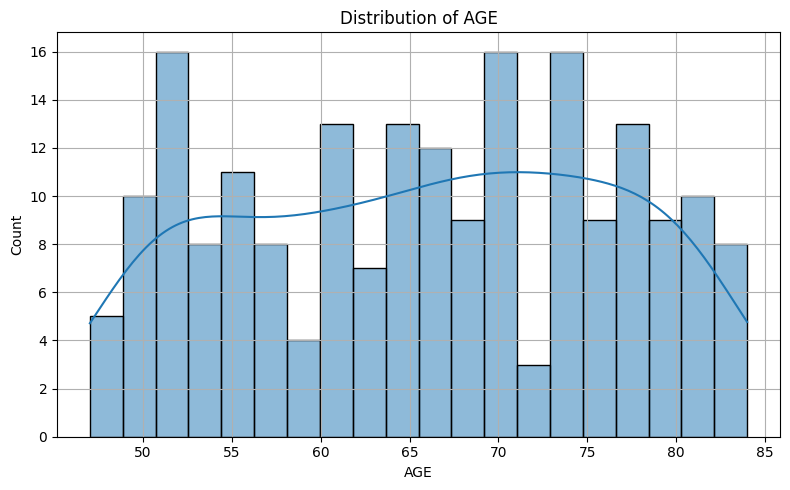


Calculating and plotting Pearson correlation heatmap...


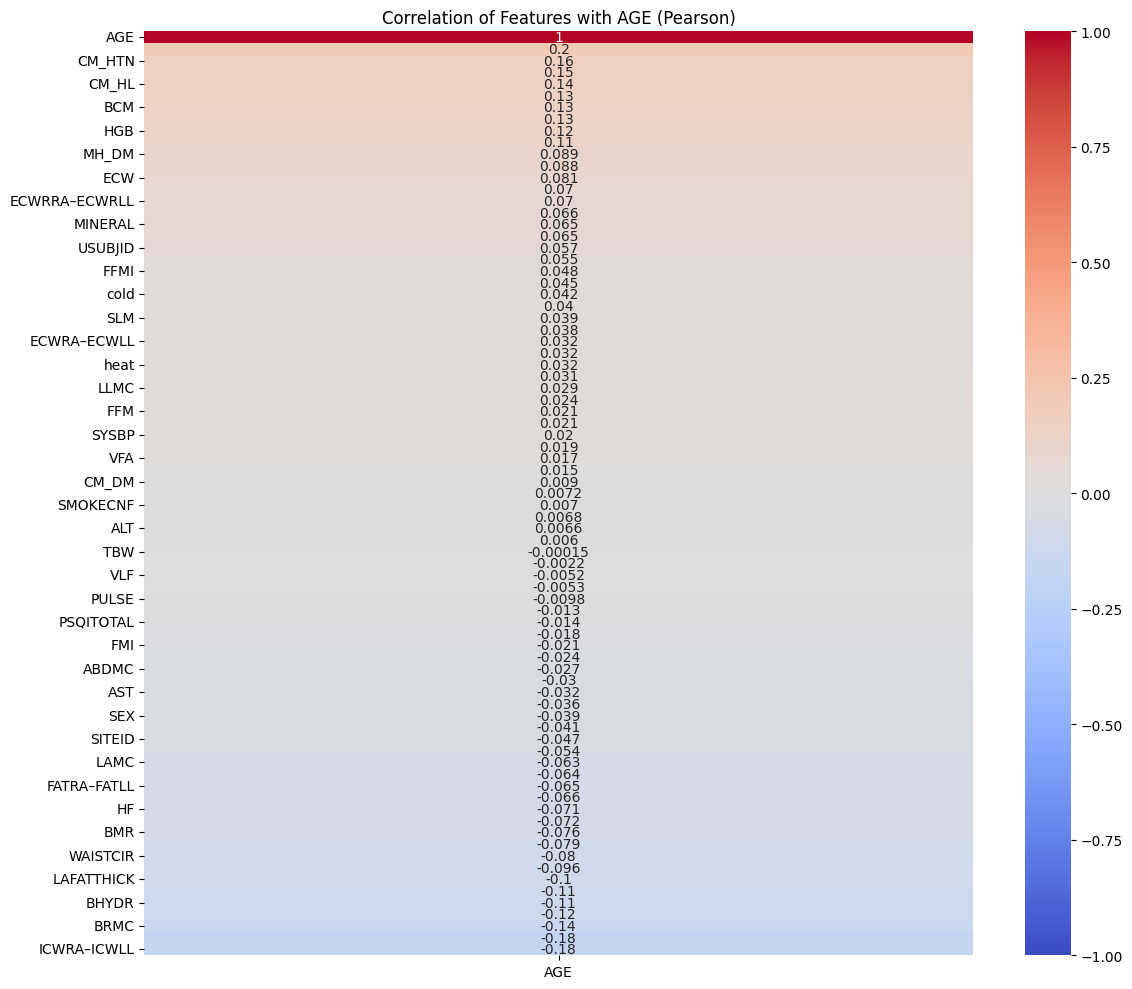


Top 10 positively correlated features with AGE:
RAMC         0.196345
CM_HTN       0.158750
ICW          0.149535
CM_HL        0.142377
LFNM         0.134828
BCM          0.130317
SLRA–SLLL    0.125187
HGB          0.121679
RLMC         0.114648
MH_DM        0.088715
Name: AGE, dtype: float64

Top 10 negatively correlated features with AGE:
BMC           -0.079213
WAISTCIR      -0.080212
GLUC          -0.096166
LAFATTHICK    -0.099659
SDNN          -0.113397
BHYDR         -0.114428
ALCOHOLYN     -0.123551
BRMC          -0.142959
ABFR          -0.178686
ICWRA–ICWLL   -0.178903
Name: AGE, dtype: float64

Generating boxplots for selected features vs AGE bins...


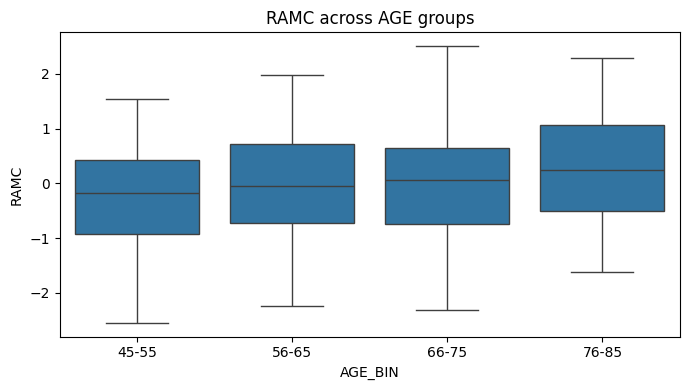

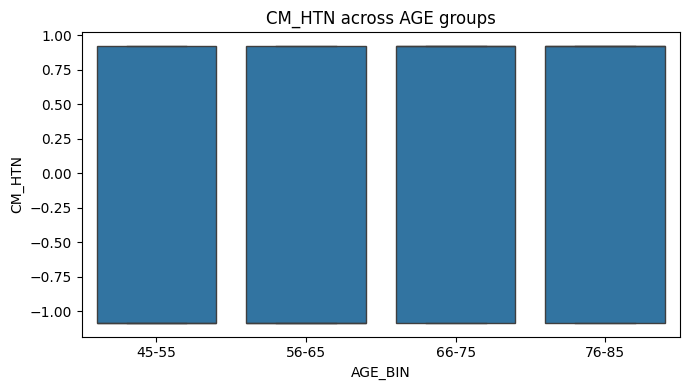

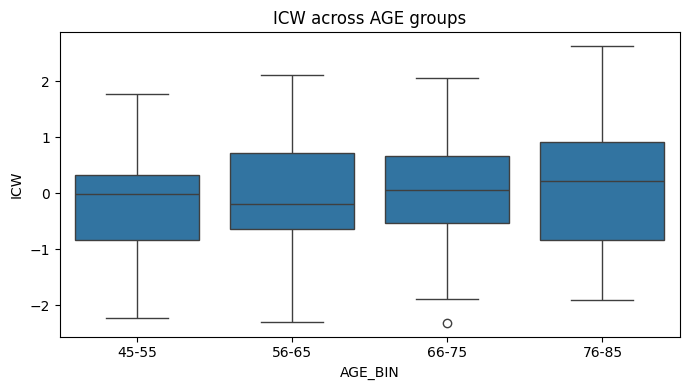

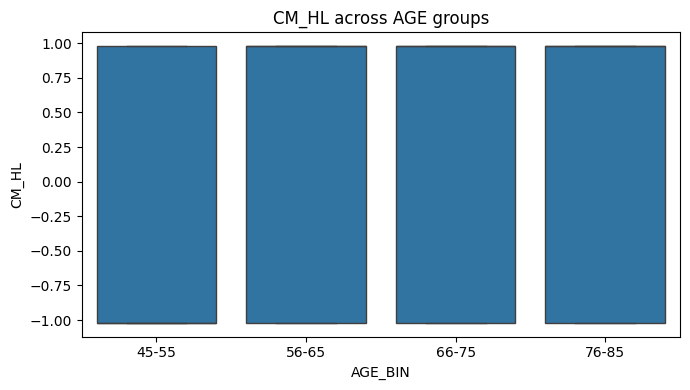

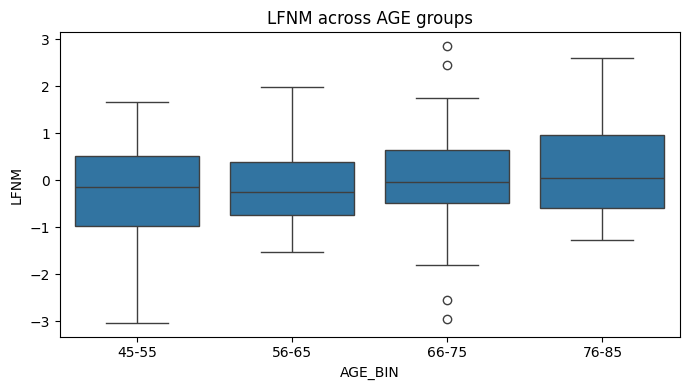

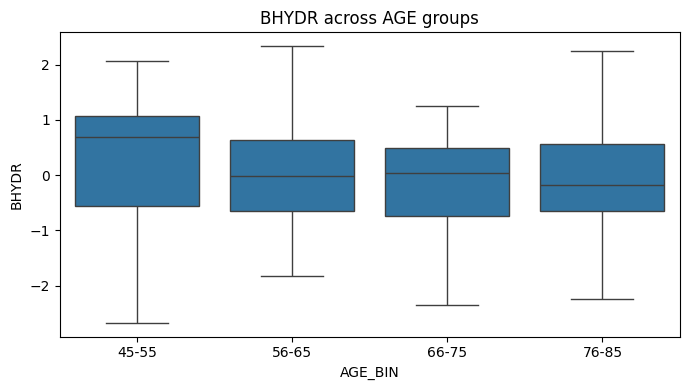

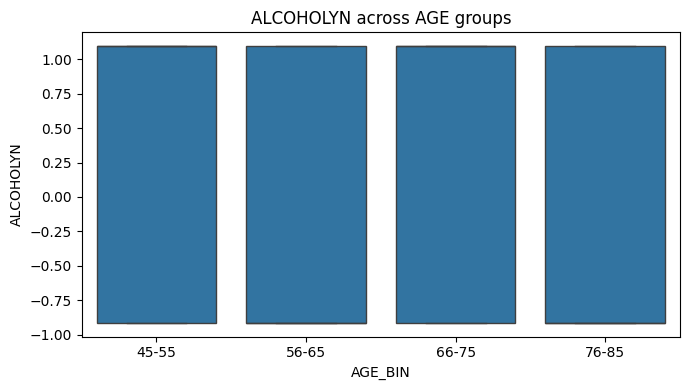

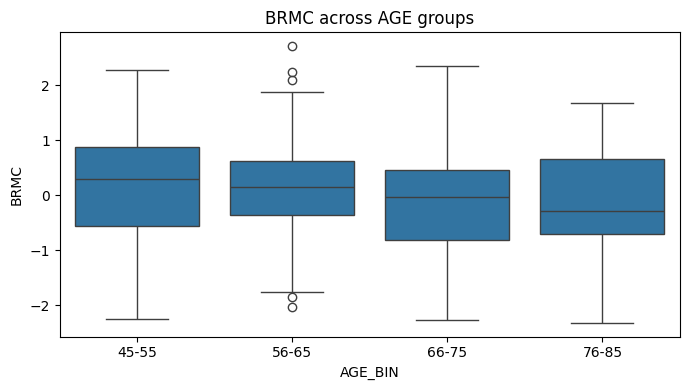

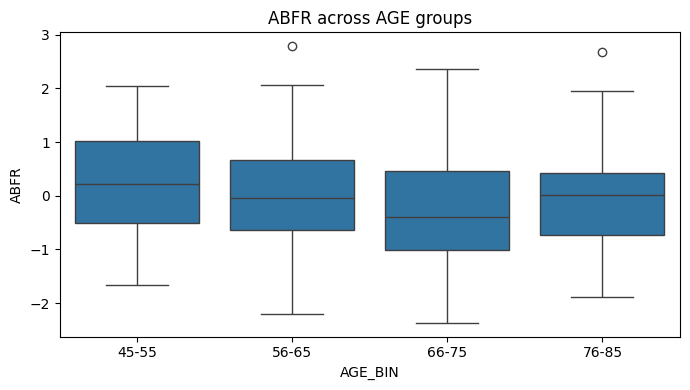

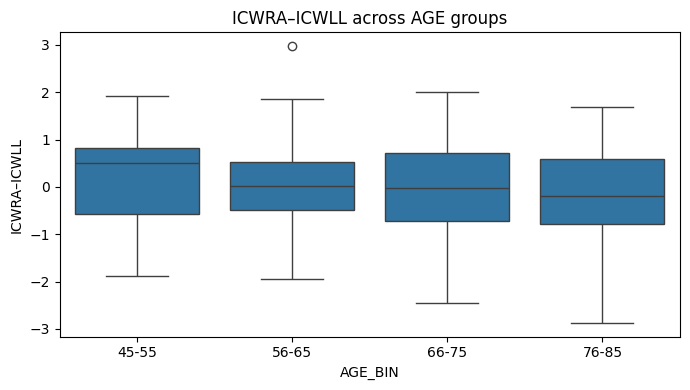


Plotting scatterplots for top correlated features vs AGE...


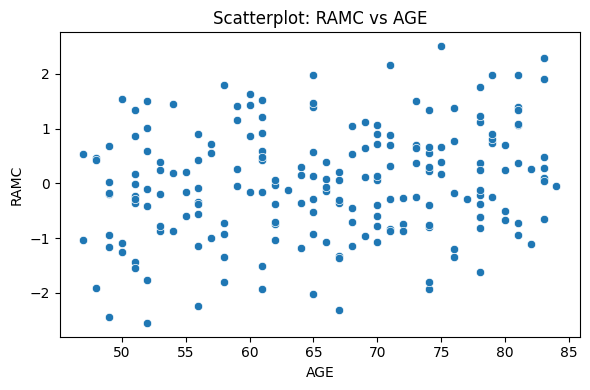

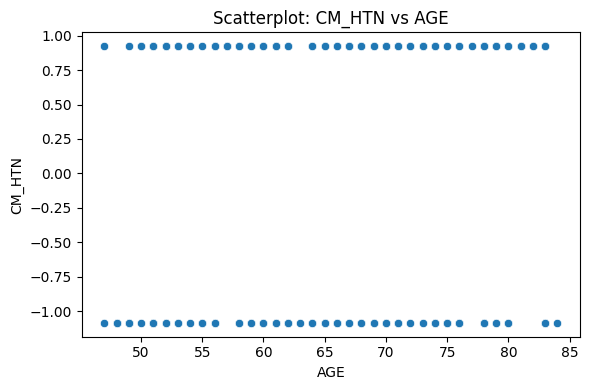

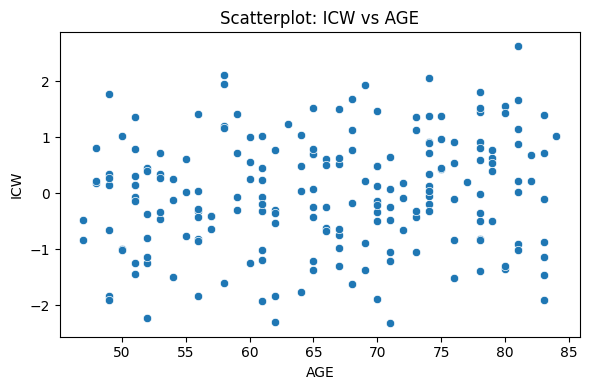

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: AGE Distribution
print("Plotting AGE distribution...")
plt.figure(figsize=(8, 5))
sns.histplot(merged_df['AGE'], kde=True, bins=20)
plt.title("Distribution of AGE")
plt.xlabel("AGE")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 2: Correlation matrix (Pearson)
print("\nCalculating and plotting Pearson correlation heatmap...")
corr_matrix = merged_df.corr(method='pearson')
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[['AGE']].sort_values(by='AGE', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of Features with AGE (Pearson)")
plt.tight_layout()
plt.show()

# Optional: Show top 10 positively and negatively correlated features
top_corr = corr_matrix['AGE'].sort_values(ascending=False)
print("\nTop 10 positively correlated features with AGE:")
print(top_corr[1:11])
print("\nTop 10 negatively correlated features with AGE:")
print(top_corr[-10:])

# Step 3: Boxplots of selected features vs AGE
selected_features = top_corr[1:6].index.tolist() + top_corr[-5:].index.tolist()

print("\nGenerating boxplots for selected features vs AGE bins...")
# Create AGE bins for visualization
merged_df['AGE_BIN'] = pd.cut(merged_df['AGE'], bins=[45, 55, 65, 75, 85], labels=["45-55", "56-65", "66-75", "76-85"])

for feature in selected_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=merged_df, x='AGE_BIN', y=feature)
    plt.title(f"{feature} across AGE groups")
    plt.tight_layout()
    plt.show()

# Step 4: Scatter plots for top 3 correlations with AGE
print("\nPlotting scatterplots for top correlated features vs AGE...")
for feature in top_corr[1:4].index:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=merged_df, x='AGE', y=feature)
    plt.title(f"Scatterplot: {feature} vs AGE")
    plt.tight_layout()
    plt.show()

# Cleanup AGE_BIN column after use
merged_df.drop(columns=['AGE_BIN'], inplace=True)


# Step 3: Feature Selection

In [16]:
!pip install boruta


  Using cached Boruta-0.4.3-py3-none-any.whl.metadata (8.8 kB)


In [18]:
!pip install eli5

  Using cached graphviz-0.20.3-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.20.3-py3-none-any.whl (47 kB)


In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Prepare features and target
X = merged_df.drop(columns=['AGE'])
y = merged_df['AGE']

# Step 1: Correlation filtering with lower threshold
print("Filtering features with correlation magnitude > 0.1 with AGE...")
correlations = merged_df.corr()['AGE'].drop('AGE')
strong_corr_features = correlations[correlations.abs() > 0.1].index.tolist()
X_corr = X[strong_corr_features]
print(f"Selected {len(strong_corr_features)} features:")
print(strong_corr_features)

# Step 2: Verify numeric types in X_corr
print("\nVerifying numeric types of selected features...")
non_numeric_cols = X_corr.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    print("Error: Non-numeric columns found:", non_numeric_cols)
    X_corr = X_corr.drop(columns=non_numeric_cols)
else:
    print("All features are numeric.")

# Step 3: LASSO Regression
print("\nRunning LASSO regression for feature selection...")
try:
    X_corr = X_corr.astype(np.float64)
    lasso = LassoCV(cv=5, random_state=42)
    lasso.fit(X_corr, y)
    lasso_features = X_corr.columns[lasso.coef_ != 0].tolist()
    print(f"Selected {len(lasso_features)} features from LASSO:")
    print(lasso_features)
except Exception as e:
    print("LASSO failed:", str(e))
    lasso_features = []

# Step 4: Mutual Information
print("\nComputing mutual information scores...")
try:
    mi_scores = mutual_info_regression(X_corr, y, random_state=42)
    mi_series = pd.Series(mi_scores, index=X_corr.columns).sort_values(ascending=False)
    mi_features = mi_series.head(10).index.tolist()
    print("Top 10 features by mutual information:")
    print(mi_features)
except Exception as e:
    print("Mutual information failed:", str(e))
    mi_features = []

# Step 5: Recursive Feature Elimination (RFE)
print("\nPerforming Recursive Feature Elimination (RFE)...")
try:
    rfe_model = RFE(estimator=RandomForestRegressor(random_state=42), n_features_to_select=10, step=1)
    rfe_model.fit(X_corr, y)
    rfe_features = X_corr.columns[rfe_model.support_].tolist()
    print("Top 10 features by RFE:")
    print(rfe_features)
except Exception as e:
    print("RFE failed:", str(e))
    rfe_features = []

# Step 6: Variance Inflation Factor (VIF)
print("\nCalculating VIF for multicollinearity...")
try:
    X_vif = sm.add_constant(X_corr)
    vif_df = pd.DataFrame()
    vif_df['feature'] = X_vif.columns
    vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    vif_df = vif_df[vif_df['feature'] != 'const'].sort_values(by='VIF', ascending=False)
    print("Top 10 features with highest VIF:")
    print(vif_df.head(10))
except Exception as e:
    print("VIF calculation failed:", str(e))
    vif_df = pd.DataFrame()

# Final: Combine selected features from all methods
print("\nFinal set of selected features (union from all methods):")
final_features = list(set(lasso_features) | set(mi_features) | set(rfe_features))
print(f"Total selected features: {len(final_features)}")
print(final_features)


Filtering features with correlation magnitude > 0.1 with AGE...
Selected 15 features:
['ALCOHOLYN', 'CM_HL', 'CM_HTN', 'HGB', 'ICW', 'SLRA–SLLL', 'ICWRA–ICWLL', 'ABFR', 'BCM', 'BRMC', 'BHYDR', 'RAMC', 'RLMC', 'LFNM', 'SDNN']

Verifying numeric types of selected features...
All features are numeric.

Running LASSO regression for feature selection...
Selected 15 features from LASSO:
['ALCOHOLYN', 'CM_HL', 'CM_HTN', 'HGB', 'ICW', 'SLRA–SLLL', 'ICWRA–ICWLL', 'ABFR', 'BCM', 'BRMC', 'BHYDR', 'RAMC', 'RLMC', 'LFNM', 'SDNN']

Computing mutual information scores...
Top 10 features by mutual information:
['HGB', 'BCM', 'SDNN', 'BRMC', 'RLMC', 'LFNM', 'ALCOHOLYN', 'CM_HL', 'CM_HTN', 'ICW']

Performing Recursive Feature Elimination (RFE)...
Top 10 features by RFE:
['HGB', 'ICW', 'SLRA–SLLL', 'ICWRA–ICWLL', 'ABFR', 'BCM', 'BRMC', 'BHYDR', 'RAMC', 'SDNN']

Calculating VIF for multicollinearity...
Top 10 features with highest VIF:
        feature       VIF
9           BCM  1.163619
3        CM_HTN  1

In [17]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy

# Prepare data
X = merged_df.drop(columns=['AGE'])
y = merged_df['AGE']

# Use only numerical features for Boruta
X_boruta = X.select_dtypes(include=[np.number]).copy()

# Ensure no missing values
assert X_boruta.isnull().sum().sum() == 0, "Missing values detected in features."

# Boruta requires numpy arrays
X_array = X_boruta.values
y_array = y.values

# Initialize RandomForestRegressor
rf = RandomForestRegressor(n_jobs=-1, max_depth=5, random_state=42)

# Initialize Boruta selector
boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    max_iter=100,
    random_state=42
)

# Fit Boruta
print("Running Boruta feature selection...")
boruta_selector.fit(X_array, y_array)

# Get selected features
selected_mask = boruta_selector.support_
selected_features = X_boruta.columns[selected_mask].tolist()
print(f"\nBoruta selected {len(selected_features)} features:")
print(selected_features)

# Optionally: weakly supported features (not confident)
weak_mask = boruta_selector.support_weak_
weak_features = X_boruta.columns[weak_mask].tolist()
if weak_features:
    print(f"\nBoruta also suggests {len(weak_features)} weakly relevant features:")
    print(weak_features)


Running Boruta feature selection...

Boruta selected 3 features:
['ABFR', 'BHYDR', 'RAMC']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression, f_classif, chi2
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import eli5
from eli5.sklearn import PermutationImportance

# Prepare data
X = merged_df.drop(columns=['AGE'])
y = merged_df['AGE']
X = X.select_dtypes(include=[np.number])
X_scaled = MinMaxScaler().fit_transform(X)

print("=== Filter Method (Model-Free) using f_regression ===")
selector_freg = SelectKBest(score_func=f_regression, k=10)
selector_freg.fit(X, y)
selected_freg = X.columns[selector_freg.get_support()].tolist()
print("Selected features:", selected_freg)

print("\n=== Univariate Feature Selection using chi2 ===")
selector_chi2 = SelectKBest(score_func=chi2, k=10)
selector_chi2.fit(X_scaled, y)
selected_chi2 = X.columns[selector_chi2.get_support()].tolist()
print("Selected features:", selected_chi2)

print("\n=== Filter Method (Statistical) using ANOVA f_classif ===")
selector_fclassif = SelectKBest(score_func=f_classif, k=10)
selector_fclassif.fit(X, y)
selected_fclassif = X.columns[selector_fclassif.get_support()].tolist()
print("Selected features:", selected_fclassif)

print("\n=== Wrapper Method using KNeighborsClassifier ===")
knn = KNeighborsClassifier(n_neighbors=3)
sfs_knn = SequentialFeatureSelector(knn, n_features_to_select=10, direction='forward')
sfs_knn.fit(X, y > y.median())
selected_knn = X.columns[sfs_knn.get_support()].tolist()
print("Selected features:", selected_knn)

print("\n=== Wrapper Method using Linear Regression ===")
linreg = LinearRegression()
sfs_lr = SequentialFeatureSelector(linreg, n_features_to_select=10, direction='forward')
sfs_lr.fit(X, y)
selected_lr = X.columns[sfs_lr.get_support()].tolist()
print("Selected features:", selected_lr)

print("\n=== Wrapper Method using RandomForestRegressor ===")
rf = RandomForestRegressor(random_state=42)
sfs_rf = SequentialFeatureSelector(rf, n_features_to_select=10, direction='forward')
sfs_rf.fit(X, y)
selected_rf = X.columns[sfs_rf.get_support()].tolist()
print("Selected features:", selected_rf)

print("\n=== Embedded Method using LassoCV ===")
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X, y)
selected_lasso = X.columns[lasso.coef_ != 0].tolist()
print("Selected features:", selected_lasso)

print("\n=== Permutation Importance using RandomForestClassifier ===")
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, (y > y.median()), random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train_bin)
perm = PermutationImportance(rf_clf, random_state=42)
perm.fit(X_test, y_test_bin)
importances = pd.Series(perm.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 features by permutation importance:")
print(importances.head(10))


=== Filter Method (Model-Free) using f_regression ===
Selected features: ['CM_HL', 'CM_HTN', 'ICW', 'SLRA–SLLL', 'ICWRA–ICWLL', 'ABFR', 'BCM', 'BRMC', 'RAMC', 'LFNM']

=== Univariate Feature Selection using chi2 ===
Selected features: ['SEX', 'MSYN', 'SMOKECNF', 'ALCOHOLYN', 'MH_HL', 'MH_HTN', 'MH_DM', 'CM_HL', 'CM_HTN', 'CM_DM']

=== Filter Method (Statistical) using ANOVA f_classif ===
Selected features: ['PULSE', 'GFRE', 'HGB', 'HIPCIR', 'SWRA–SWLL', 'ICWRA–ICWLL', 'ECWR', 'BHYDR', 'LAMC', 'HR']

=== Wrapper Method using KNeighborsClassifier ===
Selected features: ['MSYN', 'WEIGHT', 'PULSE', 'ALCOHOLYN', 'CM_HL', 'cold', 'MINERAL', 'ECWR', 'ECWRRA–ECWRLL', 'RLFATTHICK']

=== Wrapper Method using Linear Regression ===
Selected features: ['SITEID', 'MH_DM', 'CM_HTN', 'ICW', 'ICWRA–ICWLL', 'ABFR', 'BRMC', 'FFMI', 'RAMC', 'LAFATTHICK']

=== Wrapper Method using RandomForestRegressor ===
